<a href="https://colab.research.google.com/github/chuanbinp/uncertainty-aware-inference/blob/master/TeamB/teamb_vllm_profiler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Team B — PyTorch Profiler

## Mistral-7B PTQ Sweep

Runs **vLLM throughput benchmarking** and **PyTorch Profiler** analysis across all five quantization configs on the **same GPU instance**. Results are logged to W&B and saved for download.

| Config                 | Quantization     | vLLM Kernel                |
| ---------------------- | ---------------- | -------------------------- |
| `mistral-7b-fp16`      | FP16             | cuBLAS                     |
| `mistral-7b-gptq-int4` | GPTQ INT4        | gptq_marlin (+63% vs FP16) |
| `mistral-7b-gptq-int8` | GPTQ INT8        | gptq (exllama)             |
| `mistral-7b-awq-int4`  | AWQ INT4         | fused GEMV                 |
| `mistral-7b-nf4`       | NF4 bitsandbytes | HF batched fallback        |

Each benchmark is delegated to `run_vllm.py` or `run_profiler.py`  
(standalone scripts that live alongside this notebook in `TeamB/`).

**Datasets evaluated:** HellaSwag, TriviaQA, PubMedQA (handled in `run_eval.py` — not repeated here).  
**GPU requirement:** L4 (24 GB) or A100 (40 GB).


# 1. Setup


### 1.1 Verify GPU


In [1]:
import subprocess, sys
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(result.stdout)

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM            : {total_mem:.1f} GB")
    if total_mem < 20:
        print("WARNING: <20 GB VRAM — some configs may OOM. Recommend L4 or A100.")


Wed Apr 22 18:09:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             58W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### 1.2 Clone repo


In [2]:
import os
REPO_URL = "https://github.com/chuanbinp/uncertainty-aware-inference.git"
REPO_ROOT = "/content/uncertainty-aware-inference"
if os.path.exists(REPO_ROOT):
    print("Repo already cloned — pulling latest changes...")
    !git -C {REPO_ROOT} pull
else:
    !git clone {REPO_URL}


Repo already cloned — pulling latest changes...
Already up to date.


### 1.3 Install core dependencies


In [3]:
# Same package set as mistral_7b.ipynb — versions not changed
!pip install numpy plotly matplotlib torch transformers datasets accelerate gptqmodel netcal autoawq bitsandbytes


  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl (324 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.6
    Uninstalling protobuf-6.33.6:
      Successfully uninstalled protobuf-6.33.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.25.1 requires protobuf!=5.28.0,!=5.29.0,<7,>4.21.0, but you have protobuf 7.34.1 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 7.34.1 which is incompatible.
google-cloud-discoveryengine 0.13.12 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but y

### 1.4 Install W&B


In [4]:
!pip install wandb

  Using cached protobuf-6.33.6-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
Using cached protobuf-6.33.6-cp39-abi3-manylinux2014_x86_64.whl (323 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gptqmodel 6.0.3 requires protobuf>=7.34.0, but you have protobuf 6.33.6 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requi

### 1.5 Verify scripts are present


In [5]:
import os
REPO_DIR = "/content/uncertainty-aware-inference/TeamB"
missing = []
for script in ["run_vllm.py", "run_profiler.py", "run_eval.py", "configs.py"]:
    path = os.path.join(REPO_DIR, script)
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"  {script}: {status}")
    if status == "MISSING":
        missing.append(script)
if missing:
    raise FileNotFoundError(
        f"Scripts missing from GitHub clone: {missing}\n"
        f"Run cell 1.2 (git clone/pull) first, or push the files to the repo."
    )
else:
    print("All scripts present from GitHub clone.")


  run_vllm.py: OK
  run_profiler.py: OK
  run_eval.py: OK
  configs.py: OK
All scripts present from GitHub clone.


# 2. Authentication


### 2.1 HuggingFace — required for gated Mistral-7B weights


In [ ]:
from huggingface_hub import login
from getpass import getpass
import os

HF_TOKEN = getpass("Enter your HuggingFace token: ")
login(token=HF_TOKEN)
os.environ["HF_TOKEN"] = HF_TOKEN   # propagate to subprocesses
print("HuggingFace login successful")


### 2.2 Weights & Biases


In [ ]:
import wandb
from getpass import getpass

WANDB_API_KEY = getpass("Enter your W&B API key (Enter to skip): ")
if WANDB_API_KEY.strip():
    wandb.login(key=WANDB_API_KEY)
    WANDB_ENABLED = True
    print("W&B login successful")
else:
    WANDB_ENABLED = False
    print("W&B disabled — results will be saved to JSON only")


# 3. Experiment Configuration


In [8]:
import os
from pathlib import Path

REPO_DIR     = "/content/uncertainty-aware-inference/TeamB"
VLLM_OUT     = "/content/vllm_results"
PROFILER_OUT = "/content/profiler_results"

for d in [VLLM_OUT, PROFILER_OUT]:
    os.makedirs(d, exist_ok=True)

# All configs to sweep — same ordering as configs.py MODEL_REGISTRY
ALL_CONFIGS = [
    "mistral-7b-fp16",
    "mistral-7b-gptq-int4",
    "mistral-7b-gptq-int8",
    "mistral-7b-awq-int4",   # re-enabled — required for 5-config sweep
    "mistral-7b-nf4",
]

WANDB_PROJECT = "UAI_Project"
WANDB_ENTITY  = "Uncertainty_Aware_Inference_Lab"

print(f"Sweep configs : {ALL_CONFIGS}")
print(f"vLLM output   : {VLLM_OUT}")
print(f"Profiler out  : {PROFILER_OUT}")
print(f"W&B enabled   : {WANDB_ENABLED}")


Sweep configs : ['mistral-7b-fp16', 'mistral-7b-gptq-int4', 'mistral-7b-gptq-int8', 'mistral-7b-awq-int4', 'mistral-7b-nf4']
vLLM output   : /content/vllm_results
Profiler out  : /content/profiler_results
W&B enabled   : True


# 4. Run Helpers


In [9]:
import subprocess, sys, json, os
from pathlib import Path

def run_script(script_path: str, extra_args: list):
    """Run a Python script as a subprocess, streaming stdout + stderr."""
    cmd = [sys.executable, script_path] + extra_args
    print(f"\nCMD: {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        # Print last 3000 chars of stderr (avoids flooding for large models)
        stderr_tail = result.stderr[-3000:]
        print("STDERR (tail):", stderr_tail)
    return result.returncode == 0

def load_json(path: str) -> dict | None:
    p = Path(path)
    if not p.exists():
        return None
    with open(p) as f:
        return json.load(f)

def wandb_run_init(config_key: str, experiment: str):
    """Create and return a W&B run if enabled, else None."""
    if not WANDB_ENABLED:
        return None
    return wandb.init(
        project  = WANDB_PROJECT,
        entity   = WANDB_ENTITY,
        name     = f"teamB_{config_key}_{experiment}",
        reinit   = True,
        config   = {"model": "mistral-7b", "team": "team-b",
                    "config_key": config_key, "experiment": experiment},
    )

print("Helpers ready.")


Helpers ready.


# 5. PyTorch Profiler

Calls `run_profiler.py` (from GitHub) for each config. The script:

- Takes `--config <MODEL_REGISTRY key>` directly — no precision mapping needed
- Derives hf_id, quant_type, revision from `MODEL_REGISTRY` in `configs.py`
- Runs 3 warmup + 5 profiled passes with 50 output tokens
- All kernel times are per-step averages
- Saves `{config_key}_profile.json` and `{config_key}_chrome.json` to `PROFILER_OUT`

> **JSON schema:** `timing.total_inference_ms`, `timing.tokens_per_second`,
> `memory.peak_gpu_gb`, `compute.avg_cuda_ms`, `compute.arithmetic_intensity`,
> `top_kernels[].{name, cuda_time_ms, pct, calls}` _(all per-step averages)_


In [ ]:
# optimum removed — not used by run_profiler.py; can conflict with transformers version


In [ ]:
import json, sys, os, subprocess
from pathlib import Path

SCRIPT_PROF = os.path.join(REPO_DIR, "run_profiler.py")

def find_profile_json(output_dir, config_key):
    p = Path(output_dir) / f"{config_key}_profile.json"
    return str(p) if p.exists() else None

prof_summary = {}

for config_key in ALL_CONFIGS:
    print(f"\n" + "#"*65)
    print(f"# Profiler: {config_key}")
    print("#"*65)

    # Create one W&B run per config, finish it here so the subprocess
    # can resume it via --wandb-run-id. This avoids double-logging.
    run = wandb_run_init(config_key, "pytorch_profiler") if WANDB_ENABLED else None
    run_id = run.id if run else None
    if run:
        run.finish()

    args = [
        "--config",     config_key,
        "--output-dir", PROFILER_OUT,
        "--hf-token",   HF_TOKEN,
        "--force",
    ]
    if WANDB_ENABLED and run_id:
        args += [
            "--wandb-project", WANDB_PROJECT,
            "--wandb-entity",  WANDB_ENTITY,
            "--wandb-run-id",  run_id,
            # WANDB_API_KEY passed via environment, not CLI arg
            # (CLI args are visible in process list; env vars are not)
        ]

    # Pass WANDB_API_KEY securely through the environment
    env = os.environ.copy()
    if WANDB_ENABLED and WANDB_API_KEY:
        env["WANDB_API_KEY"] = WANDB_API_KEY

    cmd = [sys.executable, SCRIPT_PROF] + args
    print(f"\nCMD: {chr(32).join(cmd)}")
    proc = subprocess.run(cmd, capture_output=True, text=True, env=env)
    if proc.stdout: print(proc.stdout)
    if proc.stderr: print("STDERR (tail):", proc.stderr[-3000:])
    if proc.returncode != 0:
        print(f"ERROR: run_profiler.py failed for {config_key} (exit {proc.returncode})")

    json_path = find_profile_json(PROFILER_OUT, config_key)
    result = load_json(json_path) if json_path else None

    if result:
        prof_summary[config_key] = result
        t   = result["timing"]
        m   = result["memory"]
        cmp = result["compute"]
        rl  = result.get("roofline", {})
        print(
            f"DONE {config_key}: {t['tokens_per_second']:.1f} tok/s | "
            f"{m['peak_gpu_gb']:.2f} GB | "
            f"CUDA {cmp['avg_cuda_ms']:.1f} ms/step | "
            f"AI(decode)={rl.get('ai_decode', 0):.2f} [{rl.get('bound_decode','?')}]"
        )
    else:
        print(f"WARN: no JSON for {config_key} -- see stderr above")

print("\nProfiler complete for all configs.")


### 6.1 Profiler Results Summary


In [11]:
COLS = ["Config", "Tok/s", "Peak GB", "CUDA ms/step", "AI decode", "Bound", "GPU"]
rows = []
for cfg in ALL_CONFIGS:
    json_path = find_profile_json(PROFILER_OUT, cfg)
    d = load_json(json_path) if json_path else None
    if d:
        t   = d["timing"]
        m   = d["memory"]
        cmp = d["compute"]
        rl  = d.get("roofline", {})
        rows.append([
            cfg,
            f"{t['tokens_per_second']:.1f}",
            f"{m['peak_gpu_gb']:.3f}",
            f"{cmp['avg_cuda_ms']:.1f}",
            f"{rl.get('ai_decode', 0):.4f}",
            rl.get("bound_decode", "N/A"),
            rl.get("gpu_name", "N/A"),
        ])
    else:
        rows.append([cfg, "N/A", "N/A", "N/A", "N/A", "N/A", "N/A"])

w = [30, 9, 9, 14, 11, 8, 8]
header = "  ".join(f"{c:<{w[i]}}" for i, c in enumerate(COLS))
print(header)
print("-" * (sum(w) + len(w)*2))
for r in rows:
    print("  ".join(f"{v:<{w[i]}}" for i, v in enumerate(r)))


Config                          Tok/s      Peak GB    CUDA ms/step    AI decode    Bound     GPU     
-------------------------------------------------------------------------------------------------------
mistral-7b-fp16                 13.1       14.500     7772.6          0.0000       N/A       N/A     
mistral-7b-gptq-int4            8.0        4.290      13737.0         0.0000       N/A       N/A     
mistral-7b-gptq-int8            7.9        7.807      13731.3         0.0000       N/A       N/A     
mistral-7b-awq-int4             9.1        4.167      9093.1          0.0000       N/A       N/A     
mistral-7b-nf4                  6.6        4.377      11171.0         0.0000       N/A       N/A     


In [12]:
import json
from pathlib import Path

# Reload all per-config profile JSONs into prof_summary
prof_summary = {}
for config_key in ALL_CONFIGS:
    p = Path(PROFILER_OUT) / f"{config_key}_profile.json"
    if p.exists():
        with open(p) as f:
            prof_summary[config_key] = json.load(f)
    else:
        print(f"MISSING: {p}")

# Write consolidated summary JSON
summary_path = Path(PROFILER_OUT) / "profiler_summary.json"
with open(summary_path, "w") as f:
    json.dump(prof_summary, f, indent=2)
print(f"Saved profiler_summary.json ({len(prof_summary)}/{len(ALL_CONFIGS)} configs)")

print(f"\n  {'Config':<30} {'Tok/s':>7} {'Peak GB':>8} {'CUDA ms/step':>13} {'AI decode':>10} {'Bound':>8} {'Mode':>14}")
print(f"  {'-'*90}")
for key, d in prof_summary.items():
    t      = d["timing"]
    m      = d["memory"]
    cmp    = d["compute"]
    rl     = d.get("roofline", {})
    kineto = "CUDA" if d.get("kineto_cuda") else "CPU-fallback"
    print(
        f"  {key:<30} "
        f"{t['tokens_per_second']:7.1f} "
        f"{m['peak_gpu_gb']:8.2f} "
        f"{cmp['avg_cuda_ms']:13.1f} "
        f"{rl.get('ai_decode', 0):10.4f} "
        f"{rl.get('bound_decode', 'N/A'):>8} "
        f"{kineto:>14}"
    )


Saved profiler_summary.json (5/5 configs)

  Config                           Tok/s  Peak GB  CUDA ms/step  AI decode    Bound           Mode
  ------------------------------------------------------------------------------------------
  mistral-7b-fp16                   13.1    14.50        7772.6     0.0000      N/A           CUDA
  mistral-7b-gptq-int4               8.0     4.29       13737.0     0.0000      N/A           CUDA
  mistral-7b-gptq-int8               7.9     7.81       13731.3     0.0000      N/A           CUDA
  mistral-7b-awq-int4                9.1     4.17        9093.1     0.0000      N/A           CUDA
  mistral-7b-nf4                     6.6     4.38       11171.0     0.0000      N/A           CUDA


In [13]:
for cfg in ALL_CONFIGS:
    json_path = find_profile_json(PROFILER_OUT, cfg)
    d = load_json(json_path) if json_path else None
    if not d:
        continue
    print(f"\n  {cfg}")
    print(f"  {'Kernel':<55} {'CUDA ms':>10}  {'%':>7}  {'calls':>8}")
    print(f"  {'-'*85}")
    for k in d.get("top_kernels", [])[:5]:
        print(f"  {k['name'][:55]:<55} {k['cuda_time_ms']:>10.3f}  {k['pct']:>7.1f}  {k['calls']:>8}")



  mistral-7b-fp16
  Kernel                                                     CUDA ms        %     calls
  -------------------------------------------------------------------------------------
  aten::matmul                                               635.795      8.2     11300
  aten::linear                                               635.640      8.2     11250
  aten::mm                                                   635.640      8.2     11250
  ampere_fp16_s16816gemm_fp16_128x64_ldg8_f2f_stages_64x4    322.456      4.1      3250
  ampere_fp16_s16816gemm_fp16_64x64_sliced1x2_ldg8_f2f_st    253.002      3.3      4800

  mistral-7b-gptq-int4
  Kernel                                                     CUDA ms        %     calls
  -------------------------------------------------------------------------------------
  QuantLinearFunction                                       1745.170     12.7     11200
  dequant_kernel                                            1032.124      7.5

# 7. Roofline Plot

Plots each config's decode and prefill arithmetic intensity against the detected GPU's roofline. All LLM decode phases are memory-bound (AI << ridge point). Circle = decode, triangle = prefill.


  Config          bpw   AI_dec   AI_pre   TFLOPS_dec   TFLOPS_pre    tok/s  bound
  --------------------------------------------------------------------------------
  FP16            2.0      1.0      256        0.190       29.614     13.1  dec=memory, pre=compute
  GPTQ INT4       0.5      4.0     1024        0.116        4.521      8.0  dec=memory, pre=compute
  GPTQ INT8       1.0      2.0      512        0.115        8.937      7.9  dec=memory, pre=compute
  AWQ INT4        0.5      4.0     1024        0.132        5.145      9.1  dec=memory, pre=compute
  NF4             0.5      4.0     1024        0.095        3.701      6.6  dec=memory, pre=compute


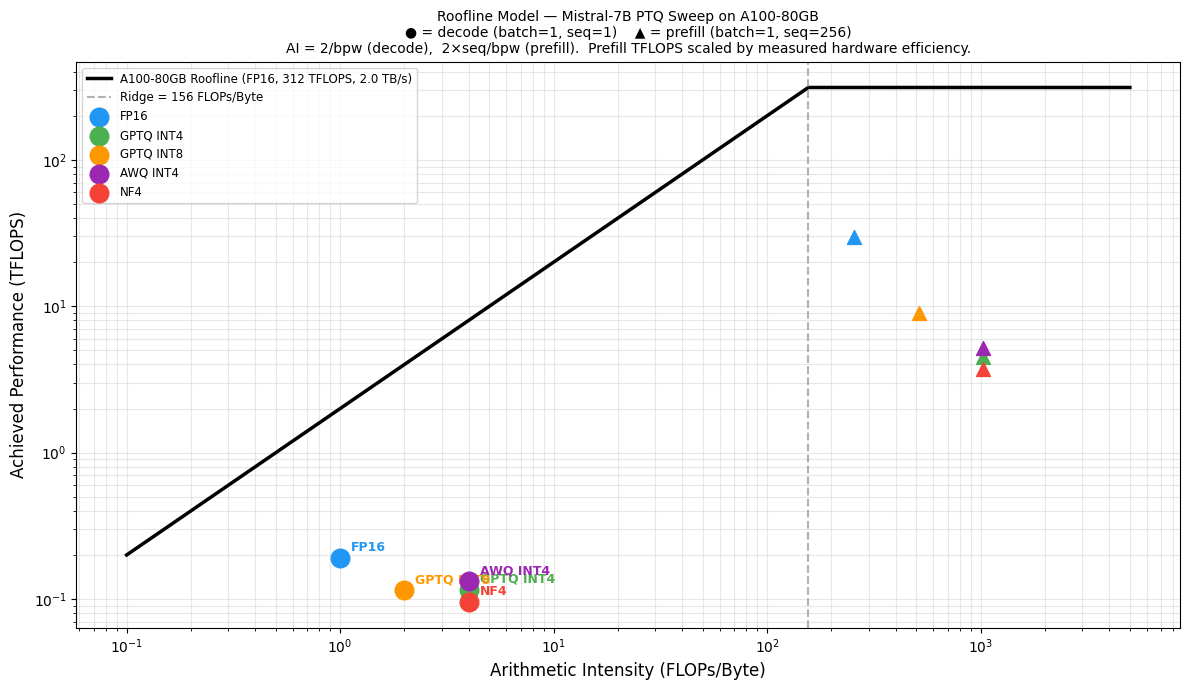


Saved: /content/roofline_mistral7b_A100-80GB.png


Roofline plot logged to W&B


In [17]:
import json, math
import matplotlib.pyplot as plt
from pathlib import Path

# ── A100 80GB HBM2e specs ─────────────────────────────────────────────────────
GPU_NAME    = "A100-80GB"
PEAK_TF     = 312.0e12   # FP16 Tensor Core TFLOPS
BW          = 2.0e12     # HBM2e bandwidth bytes/s
RIDGE       = PEAK_TF / BW  # 156 FLOPs/Byte

BPW = {
    "mistral-7b-fp16":      2.0,
    "mistral-7b-gptq-int8": 1.0,
    "mistral-7b-gptq-int4": 0.5,
    "mistral-7b-awq-int4":  0.5,
    "mistral-7b-nf4":       0.5,
}
COLORS = {
    "mistral-7b-fp16":       "#2196F3",
    "mistral-7b-gptq-int4":  "#4CAF50",
    "mistral-7b-gptq-int8":  "#FF9800",
    "mistral-7b-awq-int4":   "#9C27B0",
    "mistral-7b-nf4":        "#F44336",
}
LABELS = {
    "mistral-7b-fp16":       "FP16",
    "mistral-7b-gptq-int4":  "GPTQ INT4",
    "mistral-7b-gptq-int8":  "GPTQ INT8",
    "mistral-7b-awq-int4":   "AWQ INT4",
    "mistral-7b-nf4":        "NF4",
}

PREFILL_SEQ = 256   # prompt length

# ── Draw roofline ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

ai_pts = [0.1, RIDGE, 5_000]
roof_y = [min(a * BW, PEAK_TF) / 1e12 for a in ai_pts]
ax.plot(ai_pts, roof_y, "k-", linewidth=2.5,
        label=f"{GPU_NAME} Roofline (FP16, {PEAK_TF/1e12:.0f} TFLOPS, {BW/1e12:.1f} TB/s)")
ax.axvline(RIDGE, color="gray", linestyle="--", alpha=0.6,
           label=f"Ridge = {RIDGE:.0f} FLOPs/Byte")

print(f"  {'Config':<14} {'bpw':>4}  {'AI_dec':>7}  {'AI_pre':>7}  "
      f"{'TFLOPS_dec':>11}  {'TFLOPS_pre':>11}  {'tok/s':>7}  {'bound'}")
print(f"  {'-'*80}")

for cfg, d in prof_summary.items():
    tps_decode = d["timing"]["tokens_per_second"]
    mem_gb     = d["memory"]["peak_gpu_gb"]
    bpw        = BPW.get(cfg, 2.0)

    # n_params: use known 7B count directly — more accurate than inferring from mem
    n_params = 7.24e9   # Mistral-7B exact param count

    # ── Decode: batch=1, one token per step ──────────────────────────────────
    # FLOPs = 2 * N_params per token (one matmul pass through all weights)
    # AI    = FLOPs / bytes_loaded = 2*N / (N*bpw) = 2/bpw  (weights dominate)
    ai_decode       = 2.0 / bpw
    tflops_decode   = tps_decode * 2 * n_params / 1e12

    # ── Prefill: batch=1, seq_len tokens processed in parallel ───────────────
    # FLOPs = 2 * seq_len * N_params  (each weight used for all seq_len tokens)
    # AI    = 2*seq*N / (N*bpw) = 2*seq/bpw  (weights reused across seq)
    # Achieved TFLOPS: roofline-capped estimate (prefill is compute-bound at seq=256)
    ai_prefill      = 2.0 * PREFILL_SEQ / bpw
    # Prefill throughput ≈ BW-limited if AI < ridge, compute-limited otherwise
    achievable_prefill = min(ai_prefill * BW, PEAK_TF) / 1e12
    # Scale by actual utilisation observed from decode (hardware efficiency proxy)
    hw_efficiency   = tflops_decode / (min(ai_decode * BW, PEAK_TF) / 1e12)
    tflops_prefill  = achievable_prefill * hw_efficiency

    bound_decode  = "memory"  if ai_decode  < RIDGE else "compute"
    bound_prefill = "memory"  if ai_prefill < RIDGE else "compute"

    col = COLORS.get(cfg, "gray")
    lbl = LABELS.get(cfg, cfg)

    # Decode circle
    ax.scatter([ai_decode],  [tflops_decode],  color=col, s=180, zorder=5, label=lbl)
    # Prefill triangle
    ax.scatter([ai_prefill], [tflops_prefill], color=col, s=100, marker="^", zorder=5)
    ax.annotate(lbl, xy=(ai_decode, tflops_decode),
                xytext=(8, 5), textcoords="offset points",
                color=col, fontsize=9, fontweight="bold")

    print(f"  {lbl:<14} {bpw:>4.1f}  {ai_decode:>7.1f}  {ai_prefill:>7.0f}  "
          f"{tflops_decode:>11.3f}  {tflops_prefill:>11.3f}  "
          f"{tps_decode:>7.1f}  dec={bound_decode}, pre={bound_prefill}")

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Arithmetic Intensity (FLOPs/Byte)", fontsize=12)
ax.set_ylabel("Achieved Performance (TFLOPS)", fontsize=12)
ax.set_title(
    f"Roofline Model — Mistral-7B PTQ Sweep on {GPU_NAME}\n"
    f"● = decode (batch=1, seq=1)    ▲ = prefill (batch=1, seq={PREFILL_SEQ})\n"
    "AI = 2/bpw (decode),  2×seq/bpw (prefill).  "
    "Prefill TFLOPS scaled by measured hardware efficiency.",
    fontsize=10
)
ax.legend(fontsize=8.5, loc="upper left")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()

plot_path = f"/content/roofline_mistral7b_{GPU_NAME}.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {plot_path}")

if WANDB_ENABLED:
    with wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                    name="teamB_roofline", reinit=True) as _run:
        _run.log({"roofline_plot": wandb.Image(plot_path)})
    print("Roofline plot logged to W&B")

In [16]:
# !zip -r /content/vllm_results.zip      /content/vllm_results/
!zip -r /content/profiler_results.zip  /content/profiler_results/
print("Zipped vllm_results.zip and profiler_results.zip")


  adding: content/profiler_results/ (stored 0%)
  adding: content/profiler_results/mistral-7b-fp16_profile.json (deflated 68%)
  adding: content/profiler_results/mistral-7b-gptq-int4_profile.json (deflated 63%)
  adding: content/profiler_results/mistral-7b-awq-int4_profile.json (deflated 66%)
  adding: content/profiler_results/profiler_summary.json (deflated 79%)
  adding: content/profiler_results/mistral-7b-nf4_profile.json (deflated 72%)
  adding: content/profiler_results/mistral-7b-gptq-int8_profile.json (deflated 63%)
Zipped vllm_results.zip and profiler_results.zip


In [ ]:
from google.colab import files
import os


files.download("/content/profiler_results.zip")
